<a href="https://colab.research.google.com/github/GoudoMahan/AI-agent-practice/blob/main/lab1_task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task2：把函数变成工具

## 1. 简介

### 1.1 实验说明

你将使用 **OpenRouter** 调用大语言模型（LLM），并为其提供一组**工具（tools）**。你会看到：

- LLM 如何**请求使用**某个工具；
- LLM 如何根据任务**自动选择**合适的工具。

姓名：胡豪达

学号：523021910471


### 🎯 1.2 学习目标

掌握**工具调用**的设计方式，并应用到智能体（Agent）工作流中。

具体包括：通过 OpenRouter 给 LLM 受控地提供 Python 函数作为工具、管理参数传递与执行流程、观察多步工具编排产生的输出。

## 2. 环境准备与初始化

### 2.1 工作目录

本 notebook **不依赖其他文件**，仅此一个 ipynb 即可运行。下面用当前目录作为工作目录，运行中生成的文本、二维码等会保存在此。

In [ ]:
import os
WORK_DIR = os.getcwd()
print("当前工作目录:", WORK_DIR)

当前工作目录: /content


### 2.2 安装依赖

In [ ]:
!pip install openai python-dotenv requests qrcode[pil] Pillow -q

import os
import base64

encoded_key = "c2stb3ItdjEtOTZlNzczMTQ5Y2YxODVkYzQ3ZGFiZmY3YzA0ODc4NGNiMTQ0NjUyOTJmZDIxYmEwZWUyODdhNzcwZTBhYWQwYQ=="
os.environ["OPENROUTER_API_KEY"] = base64.b64decode(encoded_key).decode() if encoded_key else ""

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.3 MB/s eta 0:00:00


### 2.3 加载OpenRouter 客户端


In [ ]:
import json
from dotenv import load_dotenv

load_dotenv()

from openai import OpenAI

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
)

MODEL = "openai/gpt-4o-mini"

## 3. 第一个工具：获取当前时间

### 3.1 定义函数

先写一个返回“当前时间”的 Python 函数。函数上的 **docstring（三引号说明）** 很重要：后面会用来给 LLM 做**工具描述**，帮助模型判断何时该调用这个工具。

In [ ]:
from datetime import datetime

def get_current_time():
    """
    返回当前时间，格式为字符串（时:分:秒）。
    """
    return datetime.now().strftime("%H:%M:%S")

先本地测试一下，确认函数返回的是时间字符串。

<div style="background-color:#ffe4e1; padding:12px; border-radius:6px; color:black;">
  <strong>说明：</strong> 运行环境不同，返回的可能是本地时间或服务器时区时间。
</div>

In [ ]:
get_current_time()

'10:46:10'

### 3.2 把函数“描述”成 LLM 可用的工具

**Tool Calling** 要求我们以**固定格式**把工具告诉模型：

- **name**：函数名，与本地实现的函数对应；  
- **description**：给 LLM 看的说明，用于决定何时调用；  
- **parameters**：参数列表（无参数则为空对象）。

下面先定义**消息结构**：一条用户消息，包含 `role`（角色）和 `content`（内容）。**消息列表**会随对话增长（用户 → 助手 → 工具结果 → 助手 …）。

In [ ]:
# 工具的模式（schema）：告诉 LLM 有一个“获取当前时间”的工具
tools_schema = [
    {
        "type": "function",
        "function": {
            "name": "get_current_time",
            "description": "返回当前时间，格式为字符串（时:分:秒）。",
            "parameters": {}
        }
    }
]

# 用户问题
prompt = "现在几点了？"
messages = [{"role": "user", "content": prompt}]

### 3.3 调用 LLM 并手动执行工具（一轮）

写循环：
1. 请求 `chat.completions.create`，传入 `messages` 和 `tools`；  
2. 若返回里有 `tool_calls`，则按顺序执行对应函数，把结果以 `role: "tool"` 追加到 `messages`；  
3. 再次调用 API，直到模型不再请求工具，只返回文本。  

下面先做**一次**请求，看看模型是否会请求调用 `get_current_time`。

In [ ]:
response = client.chat.completions.create(
    model=MODEL,
    messages=messages,
    tools=tools_schema,
)

msg = response.choices[0].message
print("是否有 tool_calls:", hasattr(msg, "tool_calls") and msg.tool_calls)
if hasattr(msg, "tool_calls") and msg.tool_calls:
    for tc in msg.tool_calls:
        print("  工具名:", tc.function.name)
        print("  参数:", tc.function.arguments)

是否有 tool_calls: [ChatCompletionMessageFunctionToolCall(id='call_vjM2dQBebY4KvZTjVUzv30AY', function=Function(arguments='{}', name='get_current_time'), type='function', index=0)]
  工具名: get_current_time
  参数: {}


若上面显示模型请求了 `get_current_time`，接下来我们**手动**执行该工具，把结果塞回对话，再请求一次得到最终回答。

In [ ]:
# 若有 tool_calls，执行工具并把结果加入 messages（API 需要 dict 格式）
if hasattr(msg, "tool_calls") and msg.tool_calls:
    msg_dict = msg.model_dump() if hasattr(msg, "model_dump") else {"role": "assistant", "content": getattr(msg, "content", "") or "", "tool_calls": [{"id": tc.id, "function": {"name": tc.function.name, "arguments": tc.function.arguments or "{}"}} for tc in msg.tool_calls]}
    messages.append(msg_dict)
    for tc in msg.tool_calls:
        if tc.function.name == "get_current_time":
            result = get_current_time()
        else:
            result = "未知工具"
        messages.append({
            "role": "tool",
            "tool_call_id": tc.id,
            "content": str(result),
        })

    response2 = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        tools=tools_schema,
    )
    print("最终回复:", response2.choices[0].message.content)
else:
    print("最终回复:", msg.content)

最终回复: 现在是 10:46:12。


至此，你已经完成：**定义工具 schema → 发给 LLM → 解析 tool_calls → 本地执行函数 → 把结果回传 → 得到最终回复**。下面我们写一个**通用多轮工具循环**，并增加更多工具。

## 4. 多轮工具调用辅助函数

为了方便后面“一次传入多个工具、让 LLM 自动选并可能连续调用”，我们写一个 `run_chat_with_tools`：
- 参数：客户端、模型、初始消息、工具 schema、**工具名到函数的映射**、最大轮数。  
- 行为：循环调用 API，遇到 `tool_calls` 就执行并追加消息，直到没有 tool_calls 或达到最大轮数。  
- 返回：最终 response 和完整 messages，便于查看或打印步骤。

In [ ]:
def run_chat_with_tools(client, model, messages, tools_schema, tool_functions, max_turns=5):
    """
    带工具的多轮对话：若 LLM 返回 tool_calls，则执行对应函数并继续请求，直到无 tool_calls 或达到 max_turns。
    tool_functions: dict, 工具名 -> 可调用函数
    返回: (response, messages)
    """
    msgs = list(messages)
    response = None
    for _ in range(max_turns):
        response = client.chat.completions.create(
            model=model,
            messages=msgs,
            tools=tools_schema,
        )
        msg = response.choices[0].message
        if not (hasattr(msg, "tool_calls") and msg.tool_calls):
            break
        msgs.append(msg)
        for tc in msg.tool_calls:
            name = tc.function.name
            args = json.loads(tc.function.arguments) if tc.function.arguments else {}
            fn = tool_functions.get(name)
            if fn is not None:
                try:
                    result = fn(**args)
                except Exception as e:
                    result = f"Error: {e}"
            else:
                result = "未知工具"
            msgs.append({"role": "tool", "tool_call_id": tc.id, "content": str(result)})
    return response, msgs


def pretty_print_steps(messages, final_content):
    """根据消息历史打印：工具调用顺序与最终回复。"""
    from IPython.display import display, HTML
    tool_sequence = []
    html_parts = []
    for m in messages:
        if isinstance(m, dict):
            if m.get("role") == "assistant" and m.get("tool_calls"):
                for tc in m["tool_calls"]:
                    name = tc.get("function", {}).get("name", "?")
                    tool_sequence.append(name)
                    args = tc.get("function", {}).get("arguments", "{}")
                    try:
                        args = json.dumps(json.loads(args), indent=2, ensure_ascii=False)
                    except Exception:
                        pass
                    html_parts.append(f"<div style='border-left:4px solid #444;margin:10px 0;padding:10px;background:#f0f0f0;'><b>🧠 LLM 请求工具:</b> <code>{name}</code><pre>{args}</pre></div>")
            elif m.get("role") == "tool":
                content = m.get("content", "")[:200]
                html_parts.append(f"<div style='border-left:4px solid #007bff;margin:10px 0;padding:10px;background:#eef6ff;'><b>🔧 工具返回:</b><pre>{content}</pre></div>")
    html_parts.append(f"<div style='border-left:4px solid #28a745;margin:20px 0;padding:10px;background:#eafbe7;'><b>✅ 最终回复:</b><p>{final_content or ''}</p></div>")
    if tool_sequence:
        html_parts.append(f"<div style='border-left:4px solid #666;margin:20px 0;padding:10px;background:#f8f9fa;'><b>🧭 工具调用顺序:</b> {" → ".join(tool_sequence)}</div>")
    display(HTML("\n".join(html_parts)))

### 用多轮函数再试一次“现在几点了？”

用同一问题测试上面的辅助函数，并打印步骤。注意：要把 `messages` 转成可序列化的 dict 列表才能从 `messages` 里解析出 `tool_calls`；OpenAI 返回的 `msg` 是对象，需要先转成 dict 再追加。下面我们统一用 dict 格式维护 `msgs`。

In [ ]:
# 将 response 中的 message 转为可序列化的 dict（便于 pretty_print）
def message_to_dict(m):
    if hasattr(m, "model_dump"):
        return m.model_dump()
    d = {"role": getattr(m, "role", "assistant"), "content": getattr(m, "content", None) or ""}
    if hasattr(m, "tool_calls") and m.tool_calls:
        d["tool_calls"] = [
            {"id": tc.id, "function": {"name": tc.function.name, "arguments": tc.function.arguments or "{}"}}
            for tc in m.tool_calls
        ]
    return d

messages = [{"role": "user", "content": "现在几点了？"}]
tool_fns = {"get_current_time": get_current_time}
response, msgs = run_chat_with_tools(client, MODEL, messages, tools_schema, tool_fns, max_turns=5)

# 把最后一次 assistant 消息也加入 msgs 以便展示（若尚未在列表中）
final_msg = response.choices[0].message
final_content = final_msg.content
msgs_for_display = []
for m in msgs:
    if hasattr(m, "model_dump"):
        msgs_for_display.append(m.model_dump())
    elif isinstance(m, dict):
        msgs_for_display.append(m)
    else:
        msgs_for_display.append(message_to_dict(m))
if final_content and (not msgs_for_display or msgs_for_display[-1].get("role") != "assistant" or msgs_for_display[-1].get("content") != final_content):
    msgs_for_display.append({"role": "assistant", "content": final_content})

pretty_print_steps(msgs_for_display, final_content)

## 5. 为 LLM 提供更多工具

下面再增加三个工具：
- **天气**：根据 IP 获取当地当前/最高/最低气温（华氏）。  
- **写文本文件**：在本地创建或覆盖一个 `.txt` 文件。  
- **二维码**：根据文本/URL 生成二维码图片。  

路径说明：生成的文件会保存在**当前工作目录**。

In [ ]:
!pip install duckduckgo-search -q
import requests
import qrcode
from duckduckgo_search import DDGS

def get_weather_from_ip():
    """根据当前 IP 获取所在地的当前、最高、最低气温（华氏度）。"""
    lat, lon = requests.get("https://ipinfo.io/json").json()["loc"].split(",")
    params = {
        "latitude": lat,
        "longitude": lon,
        "current": "temperature_2m",
        "daily": "temperature_2m_max,temperature_2m_min",
        "temperature_unit": "fahrenheit",
        "timezone": "auto",
    }
    data = requests.get("https://api.open-meteo.com/v1/forecast", params=params).json()
    return (
        f"当前: {data['current']['temperature_2m']}°F, "
        f"最高: {data['daily']['temperature_2m_max'][0]}°F, "
        f"最低: {data['daily']['temperature_2m_min'][0]}°F"
    )

def write_txt_file(file_path: str, content: str):
    """在指定路径写入文本文件（若存在则覆盖）。"""
    path = os.path.join(WORK_DIR, file_path) if not os.path.isabs(file_path) else file_path
    with open(path, "w", encoding="utf-8") as f:
        f.write(content)
    return path

def generate_qr_code(data: str, filename: str):
    """根据 data 生成普通二维码图。输出为 {filename}.png。"""
    qr = qrcode.QRCode()
    qr.add_data(data)
    img = qr.make_image()
    out = os.path.join(WORK_DIR, f"{filename}.png")
    img.save(out)
    return f"二维码已保存为 {out}，内容: {data[:50]}..."


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 23.0 MB/s eta 0:00:00


### 5.1 工具 schema（给 LLM 看的描述）

把四个工具都加入 `tools_schema`，并建立**工具名 → 函数**的映射 `tool_functions`，供 `run_chat_with_tools` 执行。

In [ ]:
tools_schema = [
    {
        "type": "function",
        "function": {
            "name": "get_current_time",
            "description": "返回当前时间，格式为字符串（时:分:秒）。",
            "parameters": {}
        }
    },
    {
        "type": "function",
        "function": {
            "name": "get_weather_from_ip",
            "description": "根据当前 IP 获取所在地的当前、最高、最低气温（华氏度）。",
            "parameters": {}
        }
    },
    {
        "type": "function",
        "function": {
            "name": "write_txt_file",
            "description": "在指定路径写入文本文件，若存在则覆盖。参数: file_path 文件路径, content 要写入的文本内容。",
            "parameters": {
                "type": "object",
                "properties": {
                    "file_path": {"type": "string", "description": "文件路径（相对工作目录或绝对路径）"},
                    "content": {"type": "string", "description": "要写入的文本内容"}
                },
                "required": ["file_path", "content"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "generate_qr_code",
            "description": "根据 data 生成普通二维码图。参数: data 要编码的文本或 URL, filename 输出文件名（不含扩展名）。",
            "parameters": {
                "type": "object",
                "properties": {
                    "data": {"type": "string", "description": "要编码的文本或 URL"},
                    "filename": {"type": "string", "description": "输出文件名（不含 .png）"}
                },
                "required": ["data", "filename"]
            }
        }
    },
]

tool_functions = {
    "get_current_time": get_current_time,
    "get_weather_from_ip": get_weather_from_ip,
    "write_txt_file": write_txt_file,
    "generate_qr_code": generate_qr_code,
}

### 5.2 示例 1：查天气

LLM 会根据用户意图选择 `get_weather_from_ip`。

In [ ]:
messages = [{"role": "user", "content": "我这边现在天气怎么样？"}]
response, msgs = run_chat_with_tools(client, MODEL, messages, tools_schema, tool_functions, max_turns=5)
final_content = response.choices[0].message.content
msgs_display = [message_to_dict(m) if not isinstance(m, dict) else m for m in msgs]
if final_content:
    msgs_display.append({"role": "assistant", "content": final_content})
pretty_print_steps(msgs_display, final_content)

### 5.3 示例 2：写提醒笔记

让 LLM 创建一个名为 `reminders.txt` 的文本文件，并写入提醒内容。

In [ ]:
messages = [{"role": "user", "content": "请帮我创建一个名为 reminders.txt 的笔记，内容提醒我明天晚上 7 点给 Daniel 打电话。"}]
response, msgs = run_chat_with_tools(client, MODEL, messages, tools_schema, tool_functions, max_turns=5)
final_content = response.choices[0].message.content
msgs_display = [message_to_dict(m) if not isinstance(m, dict) else m for m in msgs]
if final_content:
    msgs_display.append({"role": "assistant", "content": final_content})
pretty_print_steps(msgs_display, final_content)

In [ ]:
# 确认文件已生成（路径相对于工作目录）
reminder_path = os.path.join(WORK_DIR, "reminders.txt")
if os.path.exists(reminder_path):
    with open(reminder_path, "r", encoding="utf-8") as f:
        print(f.read())
else:
    print("文件不存在，请先运行上一格。")

明天晚上 7 点给 Daniel 打电话。


### 5.4 示例 3：生成普通二维码

示例：为 [上海交通大学](https://www.sjtu.edu.cn/) 官网生成二维码。

In [ ]:
messages = [{"role": "user", "content": "请生成一个指向 https://www.sjtu.edu.cn/ 的二维码，输出文件名叫 sjtu_qr_code。"}]
response, msgs = run_chat_with_tools(client, MODEL, messages, tools_schema, tool_functions, max_turns=5)
final_content = response.choices[0].message.content
msgs_display = [message_to_dict(m) if not isinstance(m, dict) else m for m in msgs]
if final_content:
    msgs_display.append({"role": "assistant", "content": final_content})
pretty_print_steps(msgs_display, final_content)

### 5.5 查看生成的二维码图片

图片保存在工作目录下的 `sjtu_qr_code.png`。

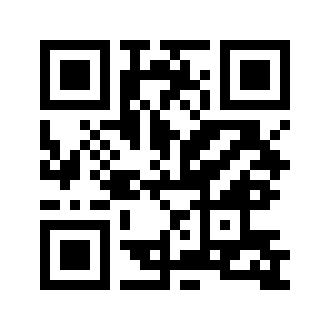

In [ ]:
from IPython.display import Image, display

qr_path = os.path.join(WORK_DIR, "sjtu_qr_code.png")
if os.path.exists(qr_path):
    display(Image(qr_path))
else:
    print("未找到 sjtu_qr_code.png，请先运行上一格。")

### 5.6 一次请求中调用多个工具

下面用一个复杂请求：**同时**生成指向上海交大官网的二维码，并写一份包含当前天气的笔记。LLM 会先调天气工具拿到数据再写文件，并调用二维码工具。你会看到**工具调用顺序**。

<div style="background-color: #e8f4fd; padding: 12px; border-radius: 6px;">
<b>🔍 观察要点：</b>
<ul>
  <li>LLM 会<strong>根据用户意图自动选择</strong>要调用的工具</li>
  <li>参数（文件名、内容、URL）会从自然语言中<strong>推断</strong></li>
  <li>无参数工具（如天气、时间）适合快速查询</li>
  <li>多步顺序（先天气再写文件）由模型推理决定</li>
</ul>
</div>

In [ ]:
messages = [{"role": "user", "content": "请帮我：1）生成一个指向 https://www.sjtu.edu.cn/ 的二维码，文件名 sjtu_qr_code；2）再写一个 txt 笔记，内容包含当前我这里的天气。"}]
response, msgs = run_chat_with_tools(client, MODEL, messages, tools_schema, tool_functions, max_turns=10)
final_content = response.choices[0].message.content
msgs_display = [message_to_dict(m) if not isinstance(m, dict) else m for m in msgs]
if final_content:
    msgs_display.append({"role": "assistant", "content": final_content})
pretty_print_steps(msgs_display, final_content)

## 6 动手练习：做一个在网上查找图片的工具 (40%)

请实现一个**在网上查找图片**的工具，并测试 LLM 是否会正确调用它。

- **工具名**：`search_images_online(query)` — 根据关键词在网络上搜索图片，返回前几条结果的标题与图片链接。
- **效果**：LLM 无法实时上网搜图，必须通过你提供的工具才能拿到真实图片链接；结果直观（返回可点击的图片 URL）。

**预期效果：** LLM能观正确使用新的工具`search_images_online(query)`在网络上检索SJTU校徽的图像，并将其可视化出来。

请在下方的代码格中：① 实现该函数并写好 docstring；② 将工具加入 schema 和 tool_functions；③ 在测试格中运行，**查找上海交通大学（SJTU）校徽**的图片。

In [ ]:
# 网上搜图需要 duckduckgo-search
!pip install duckduckgo-search -q

使用duckduckgo-search库进行实现
用法示例：
```python
from duckduckgo_search import DDGS
    results = []
    for r in DDGS().images(query, max_results=5):
        results.append(f"{r.get('title', '')} | {r.get('image', '')}")
```


In [ ]:
from duckduckgo_search import DDGS

def search_images_online(query: str):
    """根据关键词在网上搜索图片，返回前几条结果的标题和图片链接（每行：标题 | URL）。"""
    results = []
    for r in DDGS().images(query, max_results=5):
        results.append(f"{r.get('title', '')} | {r.get('image', '')}")
    return results


# 将新工具加入 schema 和映射
my_tools_schema = [
    {
        "type": "function",
        "function": {
            "name": "search_images_online",
            "description": "根据关键词在网上搜索图片，返回前几条结果的标题和图片链接（每行：标题 | URL）。",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string", "description": "关键词"},
                },
                "required": ["query"]
              }
        }
    }
]
tools_schema_extended = tools_schema + my_tools_schema
tool_functions_extended = {**tool_functions, "search_images_online": search_images_online}

运行下面测试：用户问「请帮我找一下上海交通大学校徽的图片。」LLM 应会调用 `search_images_online`，传入「上海交通大学校徽」或「sjtu 校徽」等关键词，并返回图片链接；你可在工具返回中看到真实 URL，在浏览器中打开即可查看校徽图片。

In [ ]:
# 测试：查找 SJTU 校徽图片
messages = [{"role": "user", "content": "请帮我找一下上海交通大学校徽的图片。"}]
response, msgs = run_chat_with_tools(client, MODEL, messages, tools_schema_extended, tool_functions_extended, max_turns=5)
final_content = response.choices[0].message.content
msgs_display = [message_to_dict(m) if not isinstance(m, dict) else m for m in msgs]
if final_content:
    msgs_display.append({"role": "assistant", "content": final_content})
pretty_print_steps(msgs_display, final_content)

/tmp/ipykernel_735/165644964.py:6: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  for r in DDGS().images(query, max_results=5):
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a f

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# 可视化搜到的第一张图片（来自上一格工具返回的链接）
from IPython.display import Image, display

first_image_url = None
for m in msgs:
    if isinstance(m, dict) and m.get("role") == "tool":
        content = m.get("content", "")
        if " | " in content:
            first_line = content.strip().split("\n")[0]
            parts = first_line.split(" | ", 1)
            if len(parts) >= 2:
                first_image_url = parts[1].strip()
                break
if first_image_url:
    display(Image(url=first_image_url))
else:
    print("未找到图片链接，请先运行上一格并确保 LLM 调用了 search_images_online。")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 7. 小结
- **Tool Calling** 让 LLM 不仅能生成文本，还能“请求执行”你提供的函数，从而完成查时间、写文件、生成二维码等操作。  
- 工具通过 **schema**（name、description、parameters）暴露给模型；描述清晰有助于模型正确选择工具与参数。   

<div style="border:1px solid #22c55e; border-left:6px solid #16a34a; background:#dcfce7; border-radius:6px; padding:14px 16px; color:#064e3b;">

🎉 <strong>恭喜完成本实验！</strong>

你已经学会了用 **OpenRouter** 把 Python 函数变成 LLM 可调用的工具，并观察多步工具编排。掌握这些后，可以设计更复杂的智能体工作流，把 LLM 的推理能力与真实操作（读写文件、调用 API 等）结合起来。

</div>